In [44]:
%cd /home/smalani/PartialObservations_BF/PartialObservations

import sys
sys.path.append("..")

import numpy as np
import matplotlib.pyplot as plt
from URPModel import URP_metrics
from URPModel.datagen import f_cstr, get_pars
from numpy.random import default_rng

/home/smalani/PartialObservations_BF/PartialObservations


In [2]:
from config import config
config["MODEL"]["BOX"] = 'Grey'
config["MODEL"]["Parameters"] = 'Fixed'

filename = '/home/smalani/PartialObservations_BF/PartialObservations/data/Case8a/' + "model_run_" + "0" + ".net"
network = URP_metrics.load_network(filename)

/home/smalani/PartialObservations_BF/PartialObservations/data/Case8a/model_run_0.net


In [3]:
import torch

def true_ode(t, x, Da, B, beta):
    x1, x2 = x
    dx1dt = -x1 + Da * (1-x1) * np.exp(x2)
    dx2dt = -x2 + B * Da * (1-x1) * np.exp(x2) - beta * x2
    return np.array([dx1dt, dx2dt])

def pred_ode(t, x, Da, B, beta):
    x_input = torch.from_numpy(x).to(network.device)
    if x_input.ndim > 1:
        par_input = (torch.zeros((x_input.shape[1],1)) + Da).to(network.device)
    else:
        par_input = (torch.zeros((1,)) + Da).to(network.device)
    # par_input = torch.tensor([Da]).to(network.device)
    # while par_input.ndim < x_input.ndim:
    #     par_input = par_input.unsqueeze(0)
    g = network.raw_output(x_input.T, par_input).detach().cpu().numpy()

    x1, x2 = x
    dx1dt = -x1 + g
    dx2dt = -x2 + B * g - beta * x2
    return [dx1dt, dx2dt]


/tmp/ipykernel_295747/1305576835.py:18: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3277.)
  g = network.raw_output(x_input.T, par_input).detach().cpu().numpy()


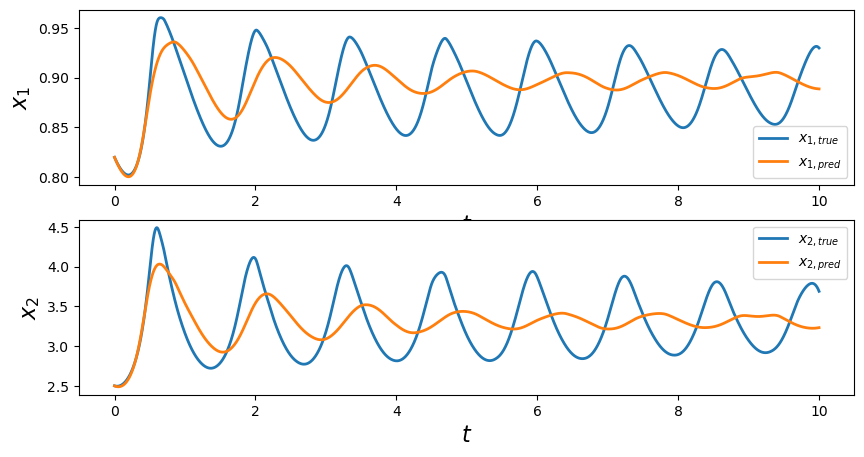

In [4]:
from scipy.integrate import solve_ivp

xin = np.array([0.82, 2.5])
Da = 0.3
B = 14.8
beta = 3
t_span = [0, 10]
t_eval = np.linspace(0, t_span[-1], 10001)

sol_true = solve_ivp(true_ode, t_span, xin, t_eval=t_eval, args=(Da, B, beta))
sol_pred = solve_ivp(pred_ode, t_span, xin, t_eval=t_eval, args=(Da, B, beta))

fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(211)
ax.plot(sol_true.t, sol_true.y[0], label='$x_{1,true}$', linewidth=2)
ax.plot(sol_pred.t, sol_pred.y[0], label='$x_{1,pred}$', linewidth=2)
ax.set_xlabel('$t$', fontsize=16)
ax.set_ylabel('$x_{1}$', fontsize=16)
ax.legend()

ax = fig.add_subplot(212)
ax.plot(sol_true.t, sol_true.y[1], label='$x_{2,true}$', linewidth=2)
ax.plot(sol_pred.t, sol_pred.y[1], label='$x_{2,pred}$', linewidth=2)
ax.set_xlabel('$t$', fontsize=16)
ax.set_ylabel('$x_{2}$', fontsize=16)
ax.legend()

/tmp/ipykernel_295747/1305576835.py:5: RuntimeWarning: overflow encountered in exp
  dx1dt = -x1 + Da * (1-x1) * np.exp(x2)
/tmp/ipykernel_295747/1305576835.py:6: RuntimeWarning: overflow encountered in exp
  dx2dt = -x2 + B * Da * (1-x1) * np.exp(x2) - beta * x2
/tmp/ipykernel_295747/1305576835.py:5: RuntimeWarning: invalid value encountered in double_scalars
  dx1dt = -x1 + Da * (1-x1) * np.exp(x2)
/tmp/ipykernel_295747/1305576835.py:6: RuntimeWarning: invalid value encountered in double_scalars
  dx2dt = -x2 + B * Da * (1-x1) * np.exp(x2) - beta * x2


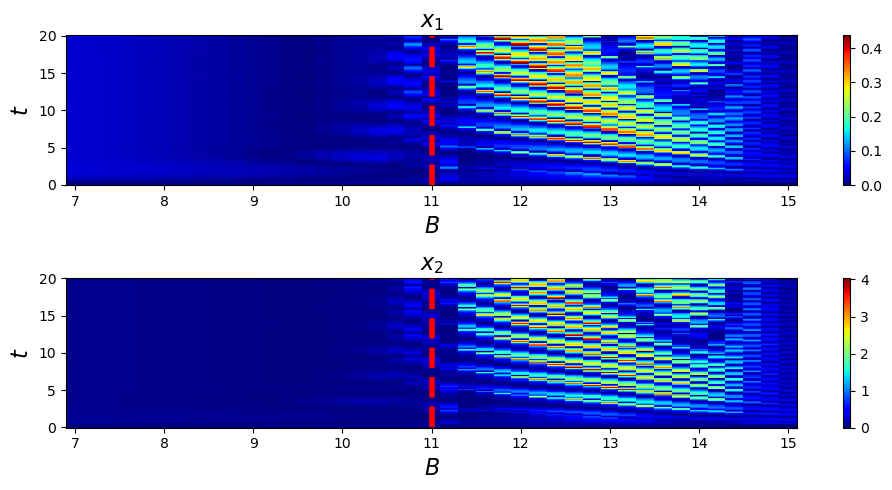

In [5]:
from scipy.integrate import solve_ivp

xin = np.array([0.82, 2.5])
Da = 0.3
# B = 11
beta = 3
t_span = [0, 20]
t_eval = np.linspace(0, 20, 201)

B_arr = np.linspace(7, 15, 41)
B_err_arr = np.zeros((2, B_arr.size, t_eval.size))

for i, B in enumerate(B_arr):
    sol_true = solve_ivp(true_ode, t_span, xin, t_eval=t_eval, args=(Da, B, beta))
    sol_pred = solve_ivp(pred_ode, t_span, xin, t_eval=t_eval, args=(Da, B, beta))

    B_err_arr[:, i, :] = np.abs(sol_true.y - sol_pred.y)

X,Y = np.meshgrid(B_arr, t_eval)

fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(211)
s = ax.pcolor(X, Y, B_err_arr[0, :, :].T, cmap='jet')
ax.set_xlabel('$B$', fontsize=16)
ax.set_ylabel('$t$', fontsize=16)
ax.set_title('$x_{1}$', fontsize=16)
ax.vlines([11], 0, 20, colors='red', linewidth=4, linestyles='dashed')
plt.colorbar(s)

ax = fig.add_subplot(212)
s = ax.pcolor(X, Y, B_err_arr[1, :, :].T, cmap='jet')
ax.set_xlabel('$B$', fontsize=16)
ax.set_ylabel('$t$', fontsize=16)
ax.set_title('$x_{2}$', fontsize=16)
ax.vlines([11], 0, 20, colors='red', linewidth=4, linestyles='dashed')
plt.colorbar(s)
plt.tight_layout()

/tmp/ipykernel_295747/1305576835.py:5: RuntimeWarning: overflow encountered in exp
  dx1dt = -x1 + Da * (1-x1) * np.exp(x2)
/tmp/ipykernel_295747/1305576835.py:6: RuntimeWarning: overflow encountered in exp
  dx2dt = -x2 + B * Da * (1-x1) * np.exp(x2) - beta * x2
/tmp/ipykernel_295747/1305576835.py:5: RuntimeWarning: invalid value encountered in double_scalars
  dx1dt = -x1 + Da * (1-x1) * np.exp(x2)
/tmp/ipykernel_295747/1305576835.py:6: RuntimeWarning: invalid value encountered in double_scalars
  dx2dt = -x2 + B * Da * (1-x1) * np.exp(x2) - beta * x2


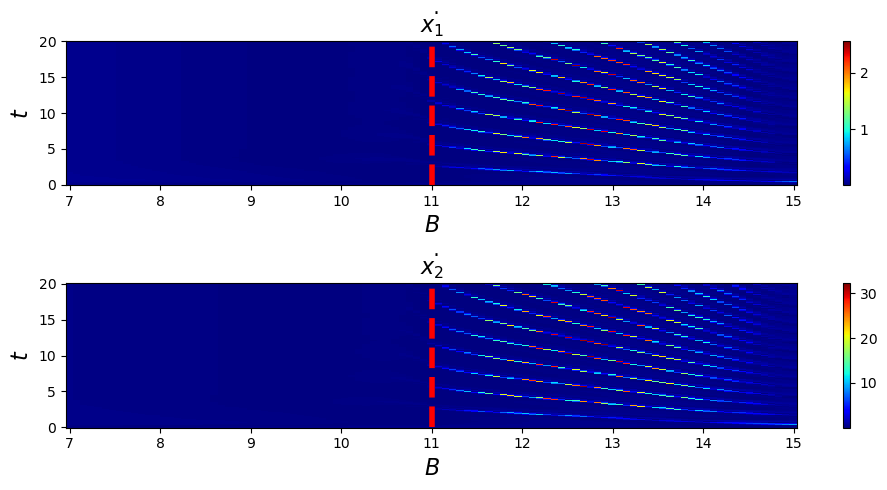

In [6]:
from scipy.integrate import solve_ivp

xin = np.array([0.82, 2.5])
Da = 0.3
# B = 11
beta = 3
t_span = [0, 20]
t_eval = np.linspace(0, 20, 201)

B_arr = np.linspace(7, 15, 101)
B_err_arr = np.zeros((2, B_arr.size, t_eval.size))

for i, B in enumerate(B_arr):
    sol_true = solve_ivp(true_ode, t_span, xin, t_eval=t_eval, args=(Da, B, beta))

    RHS_true = true_ode(0, sol_true.y, Da, B, beta)
    RHS_pred = pred_ode(0, sol_true.y, Da, B, beta)
    # sol_pred = solve_ivp(pred_ode, t_span, xin, t_eval=t_eval, args=(Da, B, beta))

    # B_err_arr[:, i, :] = np.abs(sol_true.y - sol_pred.y)
    B_err_arr[:, i, :] = np.abs(RHS_true - RHS_pred)

X,Y = np.meshgrid(B_arr, t_eval)

fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(211)
s = ax.pcolor(X, Y, B_err_arr[0, :, :].T, cmap='jet')
ax.set_xlabel('$B$', fontsize=16)
ax.set_ylabel('$t$', fontsize=16)
ax.set_title('$\\dot{x_{1}}$', fontsize=16)
ax.vlines([11], 0, 20, colors='red', linewidth=4, linestyles='dashed')
plt.colorbar(s)

ax = fig.add_subplot(212)
s = ax.pcolor(X, Y, B_err_arr[1, :, :].T, cmap='jet')
ax.set_xlabel('$B$', fontsize=16)
ax.set_ylabel('$t$', fontsize=16)
ax.set_title('$\\dot{x_{2}}$', fontsize=16)
ax.vlines([11], 0, 20, colors='red', linewidth=4, linestyles='dashed')
plt.colorbar(s)
plt.tight_layout()

/tmp/ipykernel_295747/1305576835.py:5: RuntimeWarning: overflow encountered in exp
  dx1dt = -x1 + Da * (1-x1) * np.exp(x2)
/tmp/ipykernel_295747/1305576835.py:6: RuntimeWarning: overflow encountered in exp
  dx2dt = -x2 + B * Da * (1-x1) * np.exp(x2) - beta * x2
/tmp/ipykernel_295747/1305576835.py:5: RuntimeWarning: invalid value encountered in double_scalars
  dx1dt = -x1 + Da * (1-x1) * np.exp(x2)
/tmp/ipykernel_295747/1305576835.py:6: RuntimeWarning: invalid value encountered in double_scalars
  dx2dt = -x2 + B * Da * (1-x1) * np.exp(x2) - beta * x2


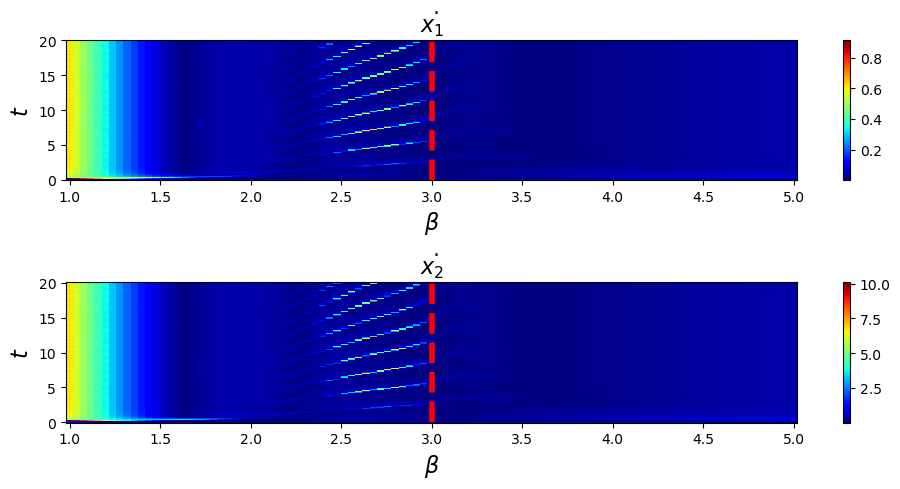

In [7]:
from scipy.integrate import solve_ivp

xin = np.array([0.82, 2.5])
Da = 0.3
B = 11
# beta = 3
t_span = [0, 20]
t_eval = np.linspace(0, 20, 201)

beta_arr = np.linspace(1, 5, 101)
beta_err_arr = np.zeros((2, B_arr.size, t_eval.size))

for i, beta in enumerate(beta_arr):
    # sol_true = solve_ivp(true_ode, t_span, xin, t_eval=t_eval, args=(Da, B, beta))
    # sol_pred = solve_ivp(pred_ode, t_span, xin, t_eval=t_eval, args=(Da, B, beta))

    # beta_err_arr[:, i, :] = np.abs(sol_true.y - sol_pred.y)

    sol_true = solve_ivp(true_ode, t_span, xin, t_eval=t_eval, args=(Da, B, beta))

    RHS_true = true_ode(0, sol_true.y, Da, B, beta)
    RHS_pred = pred_ode(0, sol_true.y, Da, B, beta)
    # sol_pred = solve_ivp(pred_ode, t_span, xin, t_eval=t_eval, args=(Da, B, beta))

    # B_err_arr[:, i, :] = np.abs(sol_true.y - sol_pred.y)
    beta_err_arr[:, i, :] = np.abs(RHS_true - RHS_pred)

X,Y = np.meshgrid(beta_arr, t_eval)

fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(211)
s = ax.pcolor(X, Y, beta_err_arr[0, :, :].T, cmap='jet')
ax.set_xlabel('$\\beta$', fontsize=16)
ax.set_ylabel('$t$', fontsize=16)
ax.set_title('$\dot{x_{1}}$', fontsize=16)
ax.vlines([3], 0, 20, colors='red', linewidth=4, linestyles='dashed')
plt.colorbar(s)

ax = fig.add_subplot(212)
s = ax.pcolor(X, Y, beta_err_arr[1, :, :].T, cmap='jet')
ax.set_xlabel('$\\beta$', fontsize=16)
ax.set_ylabel('$t$', fontsize=16)
ax.set_title('$\\dot{x_{2}}$', fontsize=16)
ax.vlines([3], 0, 20, colors='red', linewidth=4, linestyles='dashed')
plt.colorbar(s)
plt.tight_layout()

In [8]:
# from scipy.integrate import solve_ivp

# xin = np.array([0.82, 2.5])
# Da = 0.3
# B = 11
# # beta = 3
# t_span = [0, 20]
# t_eval = np.linspace(0, 20, 201)

# beta_arr = np.linspace(1, 5, 41)
# beta_err_arr = np.zeros((2, B_arr.size, t_eval.size))

# for i, beta in enumerate(beta_arr):
#     sol_true = solve_ivp(true_ode, t_span, xin, t_eval=t_eval, args=(Da, B, beta))
#     sol_pred = solve_ivp(pred_ode, t_span, xin, t_eval=t_eval, args=(Da, B, beta))

#     beta_err_arr[:, i, :] = np.abs(sol_true.y - sol_pred.y)

# X,Y = np.meshgrid(beta_arr, t_eval)

# fig = plt.figure(figsize=(10, 5))
# ax = fig.add_subplot(211)
# s = ax.pcolor(X, Y, beta_err_arr[0, :, :].T, cmap='jet')
# ax.set_xlabel('$\\beta$', fontsize=16)
# ax.set_ylabel('$t$', fontsize=16)
# ax.set_title('$x_{1}$', fontsize=16)
# ax.vlines([3], 0, 20, colors='red', linewidth=4, linestyles='dashed')
# plt.colorbar(s)

# ax = fig.add_subplot(212)
# s = ax.pcolor(X, Y, beta_err_arr[1, :, :].T, cmap='jet')
# ax.set_xlabel('$\\beta$', fontsize=16)
# ax.set_ylabel('$t$', fontsize=16)
# ax.set_title('$x_{2}$', fontsize=16)
# ax.vlines([3], 0, 20, colors='red', linewidth=4, linestyles='dashed')
# plt.colorbar(s)
# plt.tight_layout()

In [9]:
from scipy.optimize import fsolve

def ODE_Bifurc(y, func, Da, x10):
    x2, T = y
    # pars = get_pars(Da)
    
#     event = ODE_Event
#     event.terminal = True
    
    y0 = [x10, x2]

    
    sol = solve_ivp(func, y0=y0, t_span=[0, 0.1],
#                     args=pars,
                    rtol=1e-5, atol=1e-8, dense_output=True)#, events=(event,))#, dense_output=True)
    
    y_init = sol.y[:,-1]
    
    sol = solve_ivp(func, y0=y_init, t_span=[0.1, T],
#                     args=pars,
                    rtol=1e-5, atol=1e-8, dense_output=True)#, events=(event,))#, dense_output=True)
    
    T_out = sol.t[-1]
    x1_out = sol.y[0,-1]
    x2_out = sol.y[1,-1]

    return (x10-x1_out), (x2-x2_out)

##############################################################################################33

B_arr = np.sort(
            np.concatenate((
                np.linspace(10,16,100),
                np.array([11])
            ))
        )
Da = 0.3

stable_ss = []
stable_B = []

unstable_ss = []
unstable_B = []

x1max_pred = []
x1min_pred = []

x2max_pred = []
x2min_pred = []

roots = []
switch = False
root = [0.5, 1]

period = 2

for i in range(len(B_arr)):
    print(i)
    B = B_arr[i]
    beta = 3
    
    # pars = get_pars(Da)

    def torch_function(x):
        g = network.raw_output(x.unsqueeze(0).to(network.device),
                                                torch.tensor([Da]).unsqueeze(0).to(network.device))
        x1, x2 = x
        dx1dt = -x1 + g
        dx2dt = -x2 + B * g - beta * x2
        return torch.cat((dx1dt, dx2dt), dim=-1)

    def numpy_function(x):
        g = network.raw_output(torch.tensor(x).unsqueeze(0).to(network.device),
                                                   torch.tensor([Da]).unsqueeze(0).to(network.device))
        x1, x2 = x
        dx1dt = -x1 + g
        dx2dt = -x2 + B * g - beta * x2
        return torch.cat((dx1dt, dx2dt), dim=-1).detach().cpu().squeeze().numpy()

    def numpy_function_integ(t, x):
        g = network.raw_output(torch.tensor(x).unsqueeze(0).to(network.device),
                                                   torch.tensor([Da]).unsqueeze(0).to(network.device))
        x1, x2 = x
        dx1dt = -x1 + g
        dx2dt = -x2 + B * g - beta * x2
        return torch.cat((dx1dt, dx2dt), dim=-1).detach().cpu().squeeze().numpy()

    
    root = fsolve(numpy_function, root)
    J = torch.autograd.functional.jacobian(torch_function, torch.from_numpy(root), strict=True)
    w, v = np.linalg.eig(J)

    if np.any(w.real>0):
        if switch is not True:
            switch = True
            stable_ss.append(np.array([np.nan, np.nan]))
            stable_B.append(np.nan)
            
        unstable_ss.append(root)
        unstable_B.append(B)

        solved = False
        perturb = 0.1
        
        y0 = [root[1], 2]
        while not solved:
            x10 = root[0] + perturb
            

            y, infodict, ier, mesg = fsolve(ODE_Bifurc, y0, args=(numpy_function_integ, Da, x10), full_output=True)
            
            if ier == 1:
                solved = True
                y0=y

                period = y[1]
            else:
                perturb = perturb * 0.8
                
        y0_int = [x10, y[0]]
        t_eval = np.linspace(0, y[1], 1000)

        sol = solve_ivp(numpy_function_integ, y0=y0_int, t_span=[0, t_eval[-1]],
                            t_eval=t_eval,
                            rtol=1e-5, atol=1e-8)
        
        x1max_pred.append(np.max(sol.y[0,:]))
        x2max_pred.append(np.max(sol.y[1,:]))
        x1min_pred.append(np.min(sol.y[0,:]))
        x2min_pred.append(np.min(sol.y[1,:]))
                
    else:
        if switch is not False:
            switch = False
            unstable_ss.append(np.array([np.nan, np.nan]))
            unstable_B.append(np.nan)
        stable_ss.append(root)
        stable_B.append(B)

        x1max_pred.append(root[0])
        x2max_pred.append(root[1])
        x1min_pred.append(root[0])
        x2min_pred.append(root[1])

    
    roots.append(root)
roots = np.array(roots)


unstable_ss_pred = np.array(unstable_ss)
unstable_B_pred = np.array(unstable_B)
stable_ss_pred = np.array(stable_ss)
stable_B_pred = np.array(stable_B)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100


Text(0, 0.5, '$x_2$')

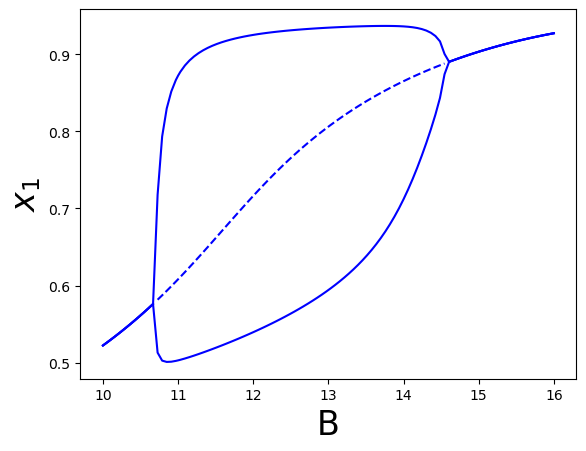

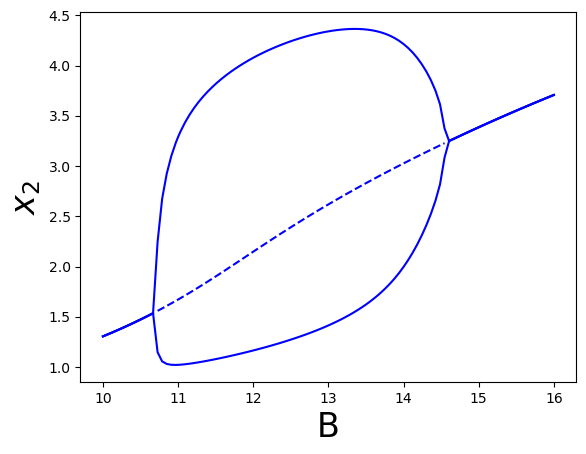

In [10]:
plt.figure()
#     plt.plot(Da_arr,roots[:,0])
if stable_B_pred.size > 0:
    plt.plot(stable_B_pred,stable_ss_pred[...,0],'b')
if unstable_B_pred.size > 0:
    plt.plot(unstable_B_pred,unstable_ss_pred[...,0],'b--')
plt.plot(B_arr, x1min_pred, 'b')
plt.plot(B_arr, x1max_pred, 'b')
plt.xlabel(r'B', fontsize=24)
plt.ylabel(r'$x_1$', fontsize=24)

plt.figure()
#     plt.plot(Da_arr,roots[:,1])
if stable_B_pred.size > 0:
    plt.plot(stable_B_pred,stable_ss_pred[...,1],'b')
if unstable_B_pred.size > 0:
    plt.plot(unstable_B_pred,unstable_ss_pred[...,1],'b--')
plt.plot(B_arr, x2min_pred, 'b')
plt.plot(B_arr, x2max_pred, 'b')
plt.xlabel(r'B', fontsize=24)
plt.ylabel(r'$x_2$', fontsize=24)

In [11]:
from scipy.optimize import fsolve

def ODE_Bifurc(y, func, Da, x10):
    x2, T = y
    # pars = get_pars(Da)
    
#     event = ODE_Event
#     event.terminal = True
    
    y0 = [x10, x2]

    
    sol = solve_ivp(func, y0=y0, t_span=[0, 0.1],
#                     args=pars,
                    rtol=1e-5, atol=1e-8, dense_output=True)#, events=(event,))#, dense_output=True)
    
    y_init = sol.y[:,-1]
    
    sol = solve_ivp(func, y0=y_init, t_span=[0.1, np.max((T,0.1))],
#                     args=pars,
                    rtol=1e-5, atol=1e-8, dense_output=True)#, events=(event,))#, dense_output=True)
    
    T_out = sol.t[-1]
    x1_out = sol.y[0,-1]
    x2_out = sol.y[1,-1]

    return (x10-x1_out), (x2-x2_out)

##############################################################################################33

B_arr = np.sort(
            np.concatenate((
                np.linspace(10,16,100),
                np.array([11])
            ))
        )

Da = 0.3

stable_ss = []
stable_B = []

unstable_ss = []
unstable_B = []

x1max_true = []
x1min_true = []

x2max_true = []
x2min_true = []

true_LC_B = []

roots = []
switch = False
root = [0.5, 1]

period = 2
for i in range(len(B_arr)):
    print(i)
    B = B_arr[i]
    beta = 3
    
    # pars = get_pars(Da)
    # def true_ode(t, x, Da, B, beta):
    #     x1, x2 = x
    #     dx1dt = -x1 + Da * (1-x1) * np.exp(x2)
    #     dx2dt = -x2 + B * Da * (1-x1) * np.exp(x2) - beta * x2
    #     return np.array([dx1dt, dx2dt])

    def torch_function(x):
        x1, x2 = x
        dx1dt = -x1 + Da * (1-x1) * torch.exp(x2)
        dx2dt = -x2 + B * Da * (1-x1) * torch.exp(x2) - beta * x2
        return torch.stack((dx1dt, dx2dt), dim=-1)

    def numpy_function(x):
        x1, x2 = x
        dx1dt = -x1 + Da * (1-x1) * np.exp(x2)
        dx2dt = -x2 + B * Da * (1-x1) * np.exp(x2) - beta * x2
        return np.stack((dx1dt, dx2dt), axis=-1)

    def numpy_function_integ(t, x):
        x1, x2 = x
        dx1dt = -x1 + Da * (1-x1) * np.exp(x2)
        dx2dt = -x2 + B * Da * (1-x1) * np.exp(x2) - beta * x2
        return np.stack((dx1dt, dx2dt), axis=-1)

    
    root = fsolve(numpy_function, root)
    J = torch.autograd.functional.jacobian(torch_function, torch.from_numpy(root), strict=True)
    w, v = np.linalg.eig(J)

    if np.any(w.real>0):
        if switch is not True:
            switch = True
            stable_ss.append(np.array([np.nan, np.nan]))
            stable_B.append(np.nan)
            
        unstable_ss.append(root)
        unstable_B.append(B)

        solved = False
        perturb = 0.1
        
        y0 = [root[1], period]
        while not solved:
            x10 = root[0] + perturb
            

            y, infodict, ier, mesg = fsolve(ODE_Bifurc, y0, args=(numpy_function_integ, Da, x10), full_output=True)
            
            if ier == 1:
                solved = True
                y0=y
            else:
                perturb = perturb * 0.8

            period = y[1]
                
        y0_int = [x10, y[0]]
        t_eval = np.linspace(0, y[1], 1000)

        sol = solve_ivp(numpy_function_integ, y0=y0_int, t_span=[0, t_eval[-1]],
                            t_eval=t_eval,
                            rtol=1e-5, atol=1e-8)
        
        x1max_true.append(np.max(sol.y[0,:]))
        x2max_true.append(np.max(sol.y[1,:]))
        x1min_true.append(np.min(sol.y[0,:]))
        x2min_true.append(np.min(sol.y[1,:]))

        y0_int = [x10, y[0]]
        t_eval = np.linspace(0, y[1], 100)

        sol = solve_ivp(numpy_function_integ, y0=y0_int, t_span=[0, t_eval[-1]],
                            t_eval=t_eval,
                            rtol=1e-5, atol=1e-8)

        true_LC_B.append(sol.y)
                
    else:
        if switch is not False:
            switch = False
            unstable_ss.append(np.array([np.nan, np.nan]))
            unstable_B.append(np.nan)
        stable_ss.append(root)
        stable_B.append(B)

        x1max_true.append(root[0])
        x2max_true.append(root[1])
        x1min_true.append(root[0])
        x2min_true.append(root[1])

        true_LC_B.append(np.array([root[0], root[1]]))

    
    roots.append(root)
roots = np.array(roots)


unstable_ss_true = np.array(unstable_ss)
unstable_B_true = np.array(unstable_B)
stable_ss_true = np.array(stable_ss)
stable_B_true = np.array(stable_B)
# true_LC_B = np.array(true_LC_B)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60


/tmp/ipykernel_295747/413113732.py:85: RuntimeWarning: overflow encountered in exp
  dx1dt = -x1 + Da * (1-x1) * np.exp(x2)
/tmp/ipykernel_295747/413113732.py:86: RuntimeWarning: overflow encountered in exp
  dx2dt = -x2 + B * Da * (1-x1) * np.exp(x2) - beta * x2
/tmp/ipykernel_295747/413113732.py:85: RuntimeWarning: invalid value encountered in double_scalars
  dx1dt = -x1 + Da * (1-x1) * np.exp(x2)
/tmp/ipykernel_295747/413113732.py:86: RuntimeWarning: invalid value encountered in double_scalars
  dx2dt = -x2 + B * Da * (1-x1) * np.exp(x2) - beta * x2


61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100


In [12]:
B_arr.shape

(101,)

In [13]:
sol.y.shape

(2, 100)

Text(0, 0.5, '$x_2$')

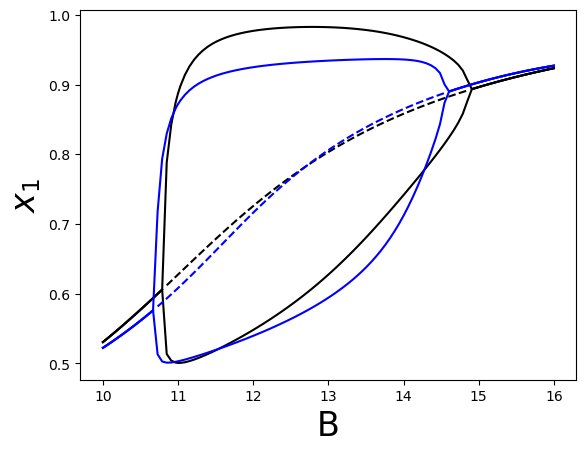

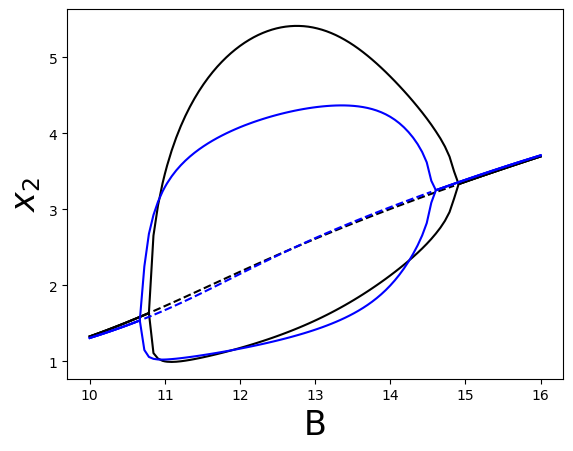

In [14]:
plt.figure()
if stable_B_true.size > 0:
    plt.plot(stable_B_true,stable_ss_true[...,0],'k')
if unstable_B_true.size > 0:
    plt.plot(unstable_B_true,unstable_ss_true[...,0],'k--')
plt.plot(B_arr, x1min_true, 'k')
plt.plot(B_arr, x1max_true, 'k')

if stable_B_pred.size > 0:
    plt.plot(stable_B_pred,stable_ss_pred[...,0],'b')
if unstable_B_pred.size > 0:
    plt.plot(unstable_B_pred,unstable_ss_pred[...,0],'b--')
plt.plot(B_arr, x1min_pred, 'b')
plt.plot(B_arr, x1max_pred, 'b')

plt.xlabel(r'B', fontsize=24)
plt.ylabel(r'$x_1$', fontsize=24)

plt.figure()
if stable_B_true.size > 0:
    plt.plot(stable_B_true,stable_ss_true[...,1],'k')
if unstable_B_true.size > 0:
    plt.plot(unstable_B_true,unstable_ss_true[...,1],'k--')
plt.plot(B_arr, x2min_true, 'k')
plt.plot(B_arr, x2max_true, 'k')

if stable_B_pred.size > 0:
    plt.plot(stable_B_pred,stable_ss_pred[...,1],'b')
if unstable_B_pred.size > 0:
    plt.plot(unstable_B_pred,unstable_ss_pred[...,1],'b--')
plt.plot(B_arr, x2min_pred, 'b')
plt.plot(B_arr, x2max_pred, 'b')

plt.xlabel(r'B', fontsize=24)
plt.ylabel(r'$x_2$', fontsize=24)



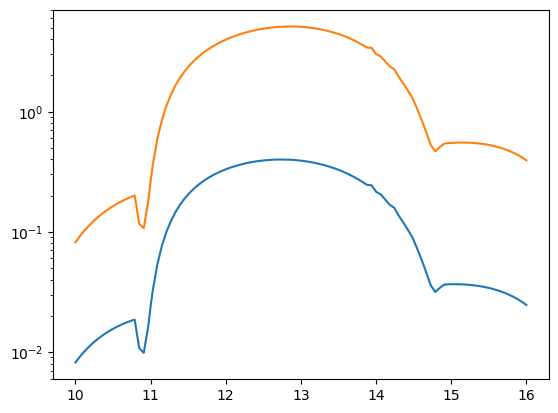

In [15]:
true_RHS_arr = []
pred_RHS_arr = []
RHS_error_arr = []

for i in range(len(true_LC_B)):
    RHS_true = np.array(true_ode(0, true_LC_B[i], Da, B_arr[i], beta))
    RHS_pred = np.array(pred_ode(0, true_LC_B[i], Da, B_arr[i], beta))

    if RHS_true.ndim == 1:
        RHS_true = RHS_true.reshape(-1,1)
        RHS_pred = RHS_pred.reshape(-1,1)

    RHS_error = np.sqrt(np.mean(((RHS_true-RHS_pred) ** 2), axis=1))
    # RHS_error = np.linalg.norm(RHS_true-RHS_pred, ord=2, axis=1)

    true_RHS_arr.append(RHS_true)
    pred_RHS_arr.append(RHS_pred)
    RHS_error_arr.append(RHS_error)

# true_RHS_arr = np.array(true_RHS_arr)
# pred_RHS_arr = np.array(pred_RHS_arr)
RHS_error_arr = np.array(RHS_error_arr)

RHS_true.shape

fig = plt.figure()
ax = fig.subplots(1,1)
ax.semilogy(B_arr, RHS_error_arr)


In [16]:
# print(B_arr[10:30])

# print(RHS_error_arr[10:30,0])

In [17]:
# RHS_true.shape

# fig = plt.figure()
# ax = fig.subplots(1,1)
# ax.semilogy(B_arr, RHS_error_arr)

In [18]:
from scipy.optimize import fsolve

def ODE_Bifurc(y, func, Da, x10):
    x2, T = y
    # pars = get_pars(Da)
    
#     event = ODE_Event
#     event.terminal = True
    
    y0 = [x10, x2]

    
    sol = solve_ivp(func, y0=y0, t_span=[0, 0.1],
#                     args=pars,
                    rtol=1e-5, atol=1e-8, dense_output=True)#, events=(event,))#, dense_output=True)
    
    y_init = sol.y[:,-1]
    
    sol = solve_ivp(func, y0=y_init, t_span=[0.1, np.max((T,0.1))],
#                     args=pars,
                    rtol=1e-5, atol=1e-8, dense_output=True)#, events=(event,))#, dense_output=True)
    
    T_out = sol.t[-1]
    x1_out = sol.y[0,-1]
    x2_out = sol.y[1,-1]

    return (x10-x1_out), (x2-x2_out)

##############################################################################################33

# beta_arr = np.linspace(1,5,100)

beta_arr = np.sort(
            np.unique(
            np.concatenate((
                np.linspace(1,5,100),
                np.array([3])
            ))
            )
        )

Da = 0.3

stable_ss = []
stable_beta = []

unstable_ss = []
unstable_beta = []

x1max_true = []
x1min_true = []

x2max_true = []
x2min_true = []

roots = []
switch = False
root = [0.5, 1]

true_LC_beta = []

for i in range(len(beta_arr)):
    # print(i)
    beta = beta_arr[i]
    B = 11
    
    # pars = get_pars(Da)
    # def true_ode(t, x, Da, B, beta):
    #     x1, x2 = x
    #     dx1dt = -x1 + Da * (1-x1) * np.exp(x2)
    #     dx2dt = -x2 + B * Da * (1-x1) * np.exp(x2) - beta * x2
    #     return np.array([dx1dt, dx2dt])

    def torch_function(x):
        x1, x2 = x
        dx1dt = -x1 + Da * (1-x1) * torch.exp(x2)
        dx2dt = -x2 + B * Da * (1-x1) * torch.exp(x2) - beta * x2
        return torch.stack((dx1dt, dx2dt), dim=-1)

    def numpy_function(x):
        x1, x2 = x
        dx1dt = -x1 + Da * (1-x1) * np.exp(x2)
        dx2dt = -x2 + B * Da * (1-x1) * np.exp(x2) - beta * x2
        return np.stack((dx1dt, dx2dt), axis=-1)

    def numpy_function_integ(t, x):
        x1, x2 = x
        dx1dt = -x1 + Da * (1-x1) * np.exp(x2)
        dx2dt = -x2 + B * Da * (1-x1) * np.exp(x2) - beta * x2
        return np.stack((dx1dt, dx2dt), axis=-1)

    
    root = fsolve(numpy_function, root)
    J = torch.autograd.functional.jacobian(torch_function, torch.from_numpy(root), strict=True)
    w, v = np.linalg.eig(J)

    if np.any(w.real>0):
        if switch is not True:
            switch = True
            stable_ss.append(np.array([np.nan, np.nan]))
            stable_beta.append(np.nan)
            
        unstable_ss.append(root)
        unstable_beta.append(beta)

        solved = False
        perturb = 0.1
        
        y0 = [root[1], 2]
        while not solved:
            x10 = root[0] + perturb
            

            y, infodict, ier, mesg = fsolve(ODE_Bifurc, y0, args=(numpy_function_integ, Da, x10), full_output=True)
            
            if ier == 1:
                solved = True
                y0=y
            else:
                perturb = perturb * 0.8
                
        y0_int = [x10, y[0]]
        t_eval = np.linspace(0, y[1], 1000)

        sol = solve_ivp(numpy_function_integ, y0=y0_int, t_span=[0, t_eval[-1]],
                            t_eval=t_eval,
                            rtol=1e-5, atol=1e-8)
        
        x1max_true.append(np.max(sol.y[0,:]))
        x2max_true.append(np.max(sol.y[1,:]))
        x1min_true.append(np.min(sol.y[0,:]))
        x2min_true.append(np.min(sol.y[1,:]))

        y0_int = [x10, y[0]]
        t_eval = np.linspace(0, y[1], 100)

        sol = solve_ivp(numpy_function_integ, y0=y0_int, t_span=[0, t_eval[-1]],
                            t_eval=t_eval,
                            rtol=1e-5, atol=1e-8)

        true_LC_beta.append(sol.y)
                
    else:
        if switch is not False:
            switch = False
            unstable_ss.append(np.array([np.nan, np.nan]))
            unstable_beta.append(np.nan)
        stable_ss.append(root)
        stable_beta.append(beta)

        x1max_true.append(root[0])
        x2max_true.append(root[1])
        x1min_true.append(root[0])
        x2min_true.append(root[1])

        true_LC_beta.append(np.array([root[0], root[1]]))

    
    roots.append(root)
roots = np.array(roots)


unstable_ss_true = np.array(unstable_ss)
unstable_beta_true = np.array(unstable_beta)
stable_ss_true = np.array(stable_ss)
stable_beta_true = np.array(stable_beta)



In [19]:
from scipy.optimize import fsolve

def ODE_Bifurc(y, func, Da, x10):
    x2, T = y
    # pars = get_pars(Da)
    
#     event = ODE_Event
#     event.terminal = True
    
    y0 = [x10, x2]

    
    sol = solve_ivp(func, y0=y0, t_span=[0, 0.1],
#                     args=pars,
                    rtol=1e-5, atol=1e-8, dense_output=True)#, events=(event,))#, dense_output=True)
    
    y_init = sol.y[:,-1]
    
    sol = solve_ivp(func, y0=y_init, t_span=[0.1, T],
#                     args=pars,
                    rtol=1e-5, atol=1e-8, dense_output=True)#, events=(event,))#, dense_output=True)
    
    T_out = sol.t[-1]
    x1_out = sol.y[0,-1]
    x2_out = sol.y[1,-1]

    return (x10-x1_out), (x2-x2_out)

##############################################################################################33

beta_arr = np.sort(
            np.unique(
            np.concatenate((
                np.linspace(1,5,100),
                np.array([3])
            ))
            )
        )
Da = 0.3

stable_ss = []
stable_beta = []

unstable_ss = []
unstable_beta = []

x1max_pred = []
x1min_pred = []

x2max_pred = []
x2min_pred = []

roots = []
switch = False
root = [0.5, 1]

period = 2

for i in range(len(beta_arr)):
    print(i)
    beta = beta_arr[i]
    B = 11
    
    # pars = get_pars(Da)

    def torch_function(x):
        g = network.raw_output(x.unsqueeze(0).to(network.device),
                                                torch.tensor([Da]).unsqueeze(0).to(network.device))
        x1, x2 = x
        dx1dt = -x1 + g
        dx2dt = -x2 + B * g - beta * x2
        return torch.cat((dx1dt, dx2dt), dim=-1)

    def numpy_function(x):
        g = network.raw_output(torch.tensor(x).unsqueeze(0).to(network.device),
                                                   torch.tensor([Da]).unsqueeze(0).to(network.device))
        x1, x2 = x
        dx1dt = -x1 + g
        dx2dt = -x2 + B * g - beta * x2
        return torch.cat((dx1dt, dx2dt), dim=-1).detach().cpu().squeeze().numpy()

    def numpy_function_integ(t, x):
        g = network.raw_output(torch.tensor(x).unsqueeze(0).to(network.device),
                                                   torch.tensor([Da]).unsqueeze(0).to(network.device))
        x1, x2 = x
        dx1dt = -x1 + g
        dx2dt = -x2 + B * g - beta * x2
        return torch.cat((dx1dt, dx2dt), dim=-1).detach().cpu().squeeze().numpy()

    
    root = fsolve(numpy_function, root)
    J = torch.autograd.functional.jacobian(torch_function, torch.from_numpy(root), strict=True)
    w, v = np.linalg.eig(J)

    if np.any(w.real>0):
        if switch is not True:
            switch = True
            stable_ss.append(np.array([np.nan, np.nan]))
            stable_beta.append(np.nan)
            
        unstable_ss.append(root)
        unstable_beta.append(beta)

        solved = False
        perturb = 0.1
        
        y0 = [root[1], 2]
        while not solved:
            x10 = root[0] + perturb
            

            y, infodict, ier, mesg = fsolve(ODE_Bifurc, y0, args=(numpy_function_integ, Da, x10), full_output=True)
            
            if ier == 1:
                solved = True
                y0=y
                period = y[1]
            else:
                perturb = perturb * 0.8
                
        y0_int = [x10, y[0]]
        t_eval = np.linspace(0, y[1], 1000)

        sol = solve_ivp(numpy_function_integ, y0=y0_int, t_span=[0, t_eval[-1]],
                            t_eval=t_eval,
                            rtol=1e-5, atol=1e-8)
        
        x1max_pred.append(np.max(sol.y[0,:]))
        x2max_pred.append(np.max(sol.y[1,:]))
        x1min_pred.append(np.min(sol.y[0,:]))
        x2min_pred.append(np.min(sol.y[1,:]))
                
    else:
        if switch is not False:
            switch = False
            unstable_ss.append(np.array([np.nan, np.nan]))
            unstable_beta.append(np.nan)
        stable_ss.append(root)
        stable_beta.append(beta)

        x1max_pred.append(root[0])
        x2max_pred.append(root[1])
        x1min_pred.append(root[0])
        x2min_pred.append(root[1])

    
    roots.append(root)
roots = np.array(roots)


unstable_ss_pred = np.array(unstable_ss)
unstable_beta_pred = np.array(unstable_beta)
stable_ss_pred = np.array(stable_ss)
stable_beta_pred = np.array(stable_beta)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100


Text(0, 0.5, '$x_2$')

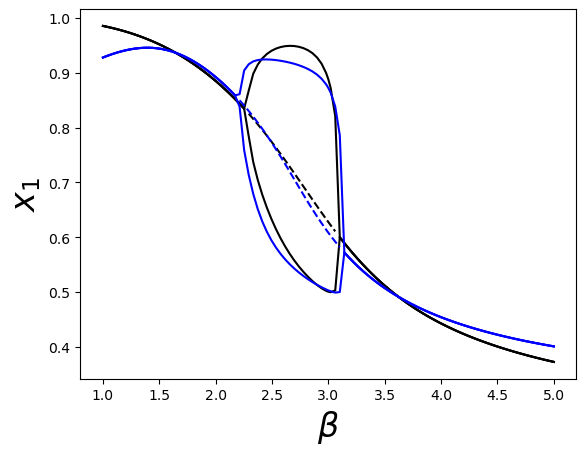

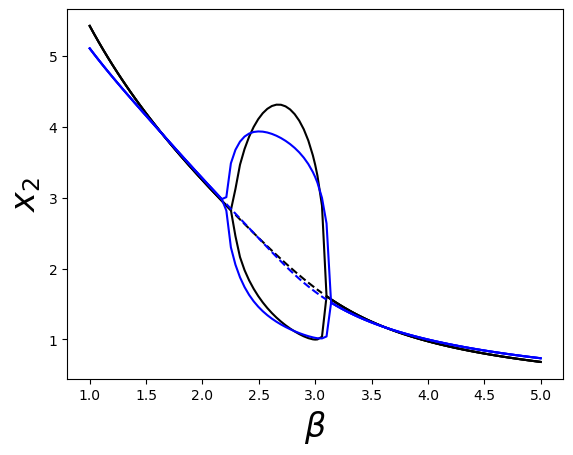

In [20]:
plt.figure()
if stable_beta_true.size > 0:
    plt.plot(stable_beta_true,stable_ss_true[...,0],'k')
if unstable_beta_true.size > 0:
    plt.plot(unstable_beta_true,unstable_ss_true[...,0],'k--')
plt.plot(beta_arr, x1min_true, 'k')
plt.plot(beta_arr, x1max_true, 'k')

if stable_beta_pred.size > 0:
    plt.plot(stable_beta_pred,stable_ss_pred[...,0],'b')
if unstable_beta_pred.size > 0:
    plt.plot(unstable_beta_pred,unstable_ss_pred[...,0],'b--')
plt.plot(beta_arr, x1min_pred, 'b')
plt.plot(beta_arr, x1max_pred, 'b')

plt.xlabel(r'$\beta$', fontsize=24)
plt.ylabel(r'$x_1$', fontsize=24)

plt.figure()
if stable_beta_true.size > 0:
    plt.plot(stable_beta_true,stable_ss_true[...,1],'k')
if unstable_beta_true.size > 0:
    plt.plot(unstable_beta_true,unstable_ss_true[...,1],'k--')
plt.plot(beta_arr, x2min_true, 'k')
plt.plot(beta_arr, x2max_true, 'k')

if stable_beta_pred.size > 0:
    plt.plot(stable_beta_pred,stable_ss_pred[...,1],'b')
if unstable_beta_pred.size > 0:
    plt.plot(unstable_beta_pred,unstable_ss_pred[...,1],'b--')
plt.plot(beta_arr, x2min_pred, 'b')
plt.plot(beta_arr, x2max_pred, 'b')

plt.xlabel(r'$\beta$', fontsize=24)
plt.ylabel(r'$x_2$', fontsize=24)



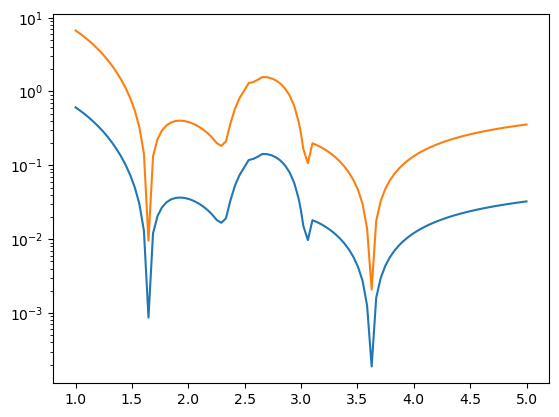

In [21]:
true_RHS_arr = []
pred_RHS_arr = []
RHS_error_arr = []

for i in range(len(true_LC_beta)):
    RHS_true = np.array(true_ode(0, true_LC_beta[i], Da, B, beta_arr[i]))
    RHS_pred = np.array(pred_ode(0, true_LC_beta[i], Da, B, beta_arr[i]))

    if RHS_true.ndim == 1:
        RHS_true = RHS_true.reshape(-1,1)
        RHS_pred = RHS_pred.reshape(-1,1)

    RHS_error = np.sqrt(np.mean(((RHS_true-RHS_pred) ** 2), axis=1))
    # RHS_error = np.linalg.norm(RHS_true-RHS_pred, ord=2, axis=1)

    true_RHS_arr.append(RHS_true)
    pred_RHS_arr.append(RHS_pred)
    RHS_error_arr.append(RHS_error)

# true_RHS_arr = np.array(true_RHS_arr)
# pred_RHS_arr = np.array(pred_RHS_arr)
RHS_error_arr = np.array(RHS_error_arr)

fig = plt.figure()
ax = fig.subplots(1,1)
ax.semilogy(beta_arr, RHS_error_arr)


In [22]:
Da_sample_raw, x1_sample, x2_sample = URP_metrics.cloud_sample()

In [23]:
x_sample = np.array([x1_sample, x2_sample])
Da_sample = Da_sample_raw.reshape(-1,1)

x_sample.shape

(2, 10000)

In [24]:
Da_sample.shape

(10000, 1)

In [25]:
def pred_ode(t, x, Da, B, beta):
    x_input = torch.from_numpy(x).to(network.device)
    if x_input.ndim > 1:
        if Da.ndim <= 1:
            par_input = (torch.zeros((x_input.shape[1],1)) + Da).to(network.device)
        else:
            par_input = torch.from_numpy(Da).to(network.device)
    else:
        par_input = (torch.zeros((1,)) + Da).to(network.device)
    # par_input = torch.tensor([Da]).to(network.device)
    # while par_input.ndim < x_input.ndim:
    #     par_input = par_input.unsqueeze(0)

    g = network.raw_output(x_input.T, par_input.T).detach().cpu().numpy()


    x1, x2 = x
    dx1dt = -x1 + g
    dx2dt = -x2 + B * g - beta * x2
    return [dx1dt, dx2dt]

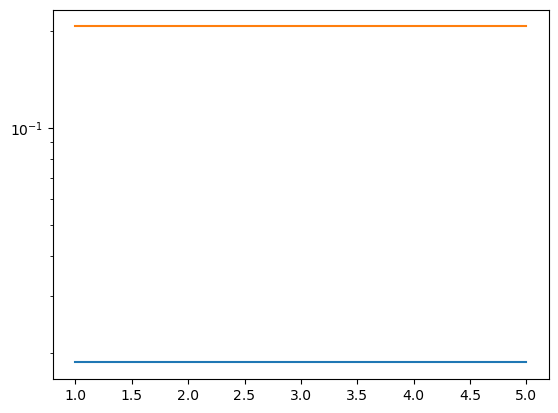

In [26]:
true_RHS_arr = []
pred_RHS_arr = []
RHS_error_arr = []

B = 11

for i in range(len(beta_arr)):
    RHS_true = np.array(true_ode(0, x_sample, Da_sample.reshape(-1,), B, beta_arr[i]))
    RHS_pred = np.array(pred_ode(0, x_sample, Da_sample.T, B, beta_arr[i]))

    if RHS_true.ndim == 1:
        RHS_true = RHS_true.reshape(-1,1)
        RHS_pred = RHS_pred.reshape(-1,1)

    RHS_error = np.sqrt(np.mean(((RHS_true-RHS_pred) ** 2), axis=1))
    # print(RHS_error)
    # RHS_error = np.linalg.norm(RHS_true-RHS_pred, ord=2, axis=1)

    true_RHS_arr.append(RHS_true)
    pred_RHS_arr.append(RHS_pred)
    RHS_error_arr.append(RHS_error)

# true_RHS_arr = np.array(true_RHS_arr)
# pred_RHS_arr = np.array(pred_RHS_arr)
RHS_error_arr = np.array(RHS_error_arr)

fig = plt.figure()
ax = fig.subplots(1,1)
ax.semilogy(beta_arr, RHS_error_arr)


ValueError: x and y must have same first dimension, but have shapes (101,) and (11, 2)

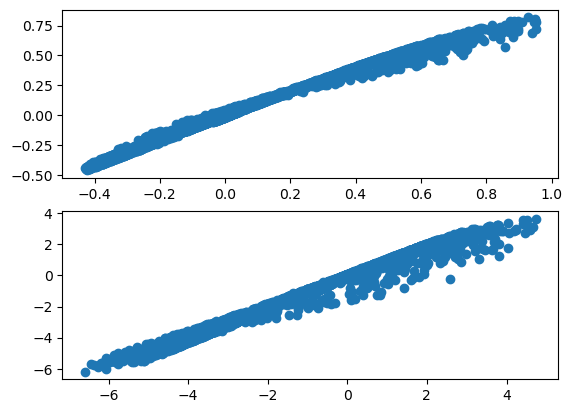

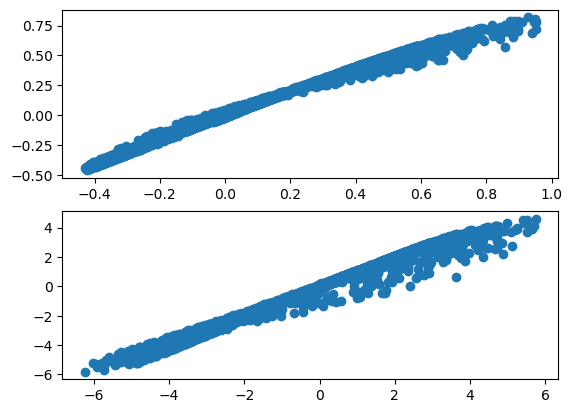

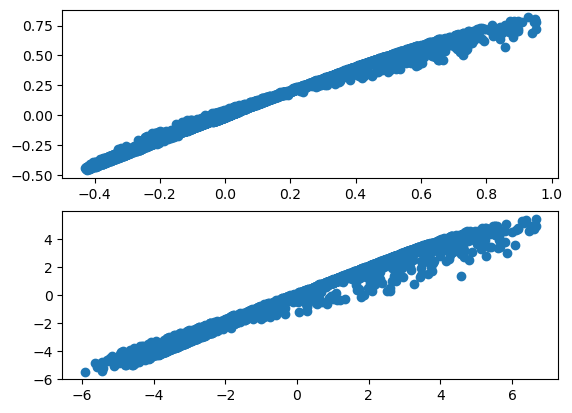

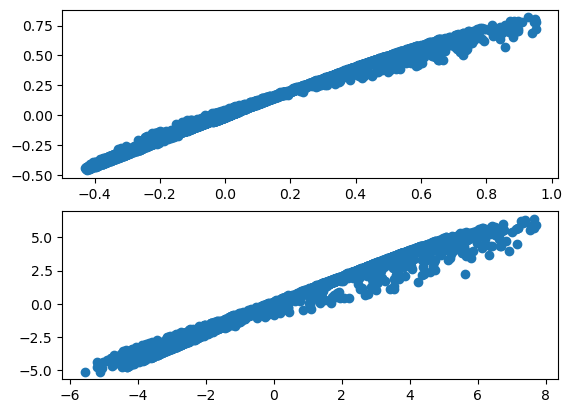

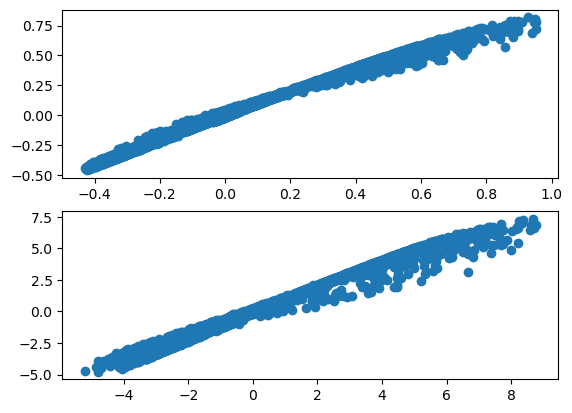

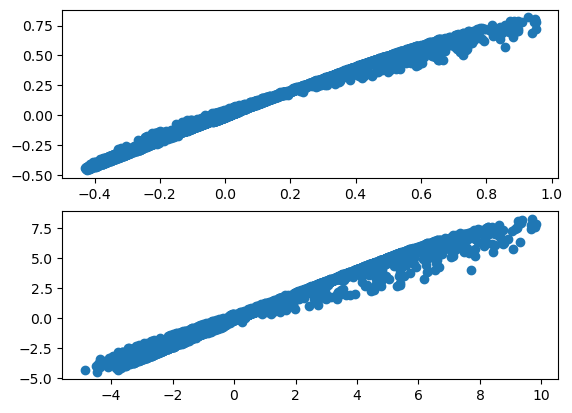

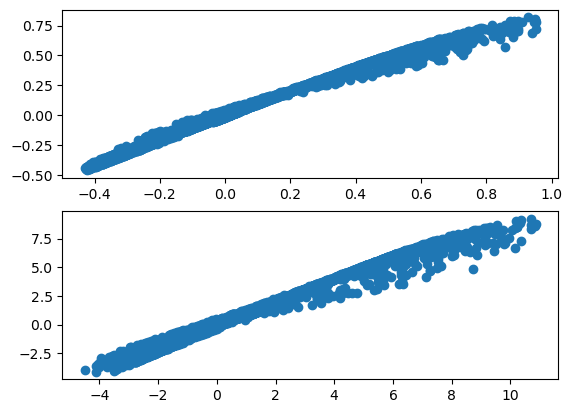

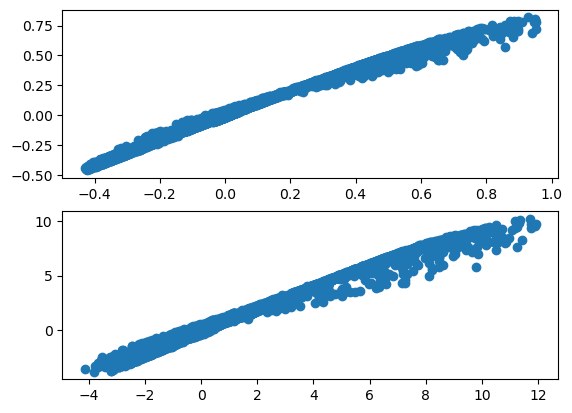

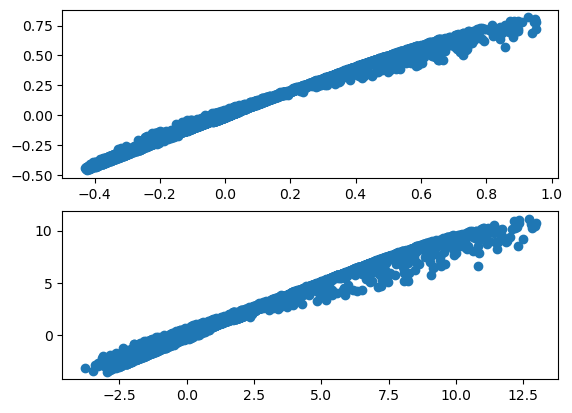

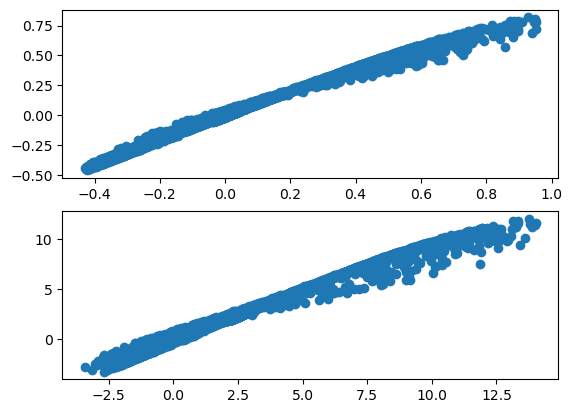

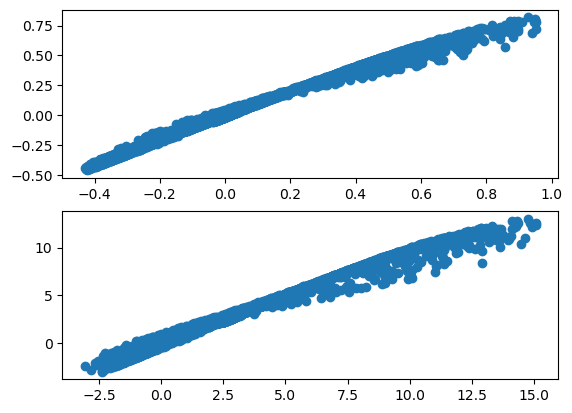

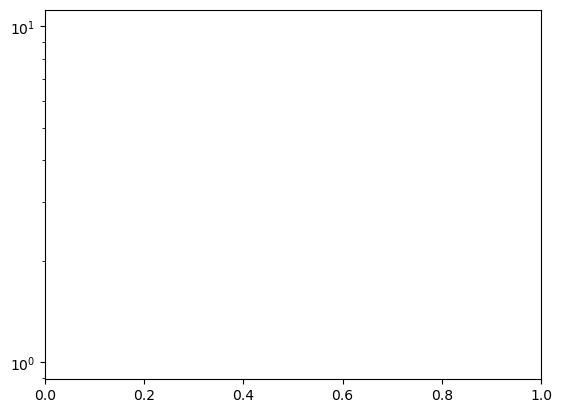

In [41]:
true_RHS_arr = []
pred_RHS_arr = []
RHS_error_arr = []

beta = 3

for i in range(len(B_arr)):
    if i % 10 != 0:
        continue
    RHS_true = np.array(true_ode(0, x_sample, Da_sample.reshape(-1,), B_arr[i], beta))
    RHS_pred = np.array(pred_ode(0, x_sample, Da_sample.T, B_arr[i], beta))

    if RHS_true.ndim == 1:
        RHS_true = RHS_true.reshape(-1,1)
        RHS_pred = RHS_pred.reshape(-1,1)

    RHS_error = np.sqrt(np.mean(((RHS_true-RHS_pred) ** 2), axis=1))
    # print(RHS_error)
    # RHS_error = np.linalg.norm(RHS_true-RHS_pred, ord=2, axis=1)

    true_RHS_arr.append(RHS_true)
    pred_RHS_arr.append(RHS_pred)
    RHS_error_arr.append(RHS_error)

    fig = plt.figure()
    ax = plt.subplot(211)
    ax.plot(RHS_true[0,:], RHS_pred[0,:], 'o')
    ax = plt.subplot(212)
    ax.plot(RHS_true[1,:], RHS_pred[1,:], 'o')
    # assert False

# true_RHS_arr = np.array(true_RHS_arr)
# pred_RHS_arr = np.array(pred_RHS_arr)
# RHS_error_arr = np.array(RHS_error_arr)

# fig = plt.figure()
# ax = fig.subplots(1,1)
# ax.semilogy(beta_arr, RHS_error_arr)


In [ ]:

unstable_ss, unstable_Da, stable_ss1, stable_Da1, stable_ss2, stable_Da2, Da_arr, x1min, x2min, x1max, x2max, x1LC, x2LC = \
        URP_metrics.make_Bifurc_true_with_LC()
network = load_network(filename)

Da_sampler = default_rng(seed=123)
LC_sampler = default_rng(seed=456)

Da_sample = np.zeros(100)
x1_sample = np.zeros(100)
x2_sample = np.zeros(100)

def my_ode(t, y, p):        
    dxdt = network.output(torch.tensor(y).to(network.device),
                            torch.tensor(p).to(network.device))
    
    return dxdt.detach().cpu().squeeze().numpy()

RHS_hair_error_trueLC_True = []
RHS_hair_error_trueLC_Pred = []

T = 1
teval = np.linspace(0, T, 100)

for i in range(x1_sample.size):
    Da_index = Da_sampler.choice(len(Da_arr))
    LC_index = LC_sampler.choice(np.array(x1LC[Da_index]).size)

    init = np.array([np.array(x1LC[Da_index]).reshape((-1))[LC_index],\
                        np.array(x2LC[Da_index]).reshape((-1))[LC_index]])
    pars_true = get_pars(Da_arr[Da_index])
    pars_ANN = np.array([Da_arr[Da_index]]).reshape((-1))

    sol_true = solve_ivp(f_cstr, y0=init, t_span=[0, T],
                            t_eval=teval, args=pars_true,
                            rtol=1e-5, atol=1e-8)

    sol_pred = solve_ivp(my_ode, y0=init, t_span=[0, T],
                            t_eval=teval, args=(pars_ANN,),
                            rtol=1e-5, atol=1e-8)

    RHS_hair_error_trueLC_True.append(sol_true.y[:,-1])
    RHS_hair_error_trueLC_Pred.append(sol_pred.y[:,-1])

RHS_hair_error_trueLC_Pred = np.array(RHS_hair_error_trueLC_Pred)
RHS_hair_error_trueLC_True = np.array(RHS_hair_error_trueLC_True)

scaler = MinMaxScaler()
scaler.fit(RHS_hair_error_trueLC_True)

RHS_hair_error_trueLC_Pred_norm = scaler.transform(RHS_hair_error_trueLC_Pred)
RHS_hair_error_trueLC_True_norm = scaler.transform(RHS_hair_error_trueLC_True)

L1_norm = np.sum(np.sum((np.abs(RHS_hair_error_trueLC_Pred_norm - RHS_hair_error_trueLC_True_norm)), axis=1), axis=0) / RHS_hair_error_trueLC_True_norm.size
L2_norm = np.sum(np.sqrt(np.sum(((RHS_hair_error_trueLC_Pred_norm - RHS_hair_error_trueLC_True_norm)**2), axis=1)), axis=0) / RHS_hair_error_trueLC_True_norm.size
Linf_norm = np.sum(np.max(np.abs(RHS_hair_error_trueLC_Pred_norm - RHS_hair_error_trueLC_True_norm), axis=1)) / RHS_hair_error_trueLC_True_norm.shape[0]